In [2]:
import sys
from pathlib import Path

import torch
from einops import rearrange
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torchvision.utils import save_image

sys.path.append(".")

import diffusion
from diffusion.data import Identity
from diffusion.guidance import ClassifierFree
from diffusion.loss import Simple
from diffusion.net import UNet
from diffusion.noise import Gaussian
from diffusion.schedule import Cosine
import numpy as np 
import numpy as np
import matplotlib.pyplot as plt

# Toy dataset

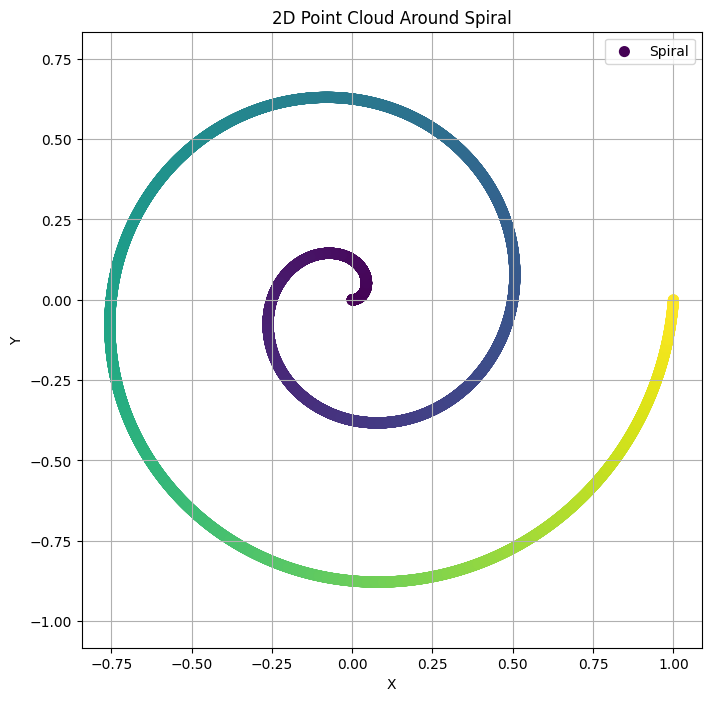

In [3]:
def generate_spiral_points(num_points, start_radius, end_radius, num_turns):
    angles = np.linspace(0, 2*np.pi*num_turns, num_points)
    radii = np.linspace(start_radius, end_radius, num_points)
    x = radii * np.cos(angles)
    y = radii * np.sin(angles)
    return x, y, angles

def generate_random_noise(num_points, max_noise):
    noise_x = np.random.uniform(-max_noise, max_noise, num_points)
    noise_y = np.random.uniform(-max_noise, max_noise, num_points)
    return noise_x, noise_y

num_points = 15000  # Increase number of points
start_radius = 0
end_radius = 5
num_turns = 2  # Increase number of turns
max_noise = 0.3  # Increase level of noise

# Generate points along the spiral
x_spiral, y_spiral, spiral_angles = generate_spiral_points(num_points, start_radius, end_radius, num_turns)
spiral_length = np.insert(np.cumsum(np.sqrt((x_spiral[:-1] - x_spiral[1:])**2 + (y_spiral[:-1] - y_spiral[1:])**2)), 0, 0)
# Add random noise to the points
noise_x, noise_y = generate_random_noise(num_points, max_noise)
x_cloud = x_spiral + noise_x
y_cloud = y_spiral + noise_y

# normalize data 
x_cloud = (x_cloud - x_cloud.min()) / (x_cloud.max() - x_cloud.min())
y_cloud = (y_cloud - y_cloud.min()) / (y_cloud.max() - y_cloud.min())

# Plot the spiral and the point cloud
plt.figure(figsize=(8, 8))
plt.scatter(x_spiral / 5, y_spiral / 5, c=spiral_length / spiral_length.max(), linewidth=2, label='Spiral', )
# plt.scatter(x_cloud, y_cloud, color='red', s=5, label='Point Cloud')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Point Cloud Around Spiral')
plt.legend()
plt.axis('equal')
plt.grid(True)
plt.show()

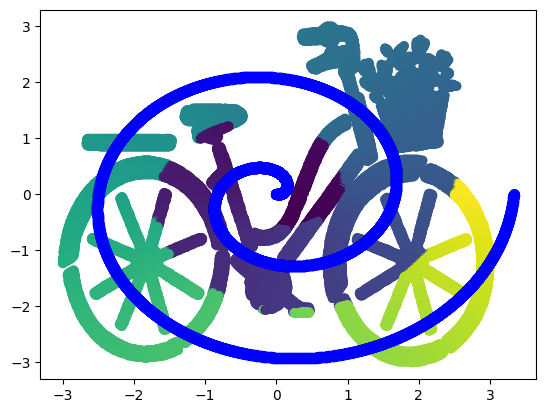

In [4]:
import numpy as np 
import numpy as np
import matplotlib.pyplot as plt

bicycle_dataset_path = Path(__name__).resolve().parents[2] / "data/bicycle.txt"
bicycle_numpy_path = Path(__name__).resolve().parents[2] / "data/bicycle.npy"
cond_closest_path = Path(__name__).resolve().parents[2] / "data/bicycle_cond_closest.npy"
cond_len_path = Path(__name__).resolve().parents[2] / "data/bicycle_cond_len_v2.npy"
cond_ang_path = Path(__name__).resolve().parents[2] / "data/bicycle_cond_angle.npy"
cond_ltr_path = Path(__name__).resolve().parents[2] / "data/bicycle_cond_ltr.npy"


def load_bicycle(path):
    points = []
    with open(path, "r") as f:
        for l in f.readlines():
            points.append(l.split())
    return np.array(points).astype(float)

def find_closest(points, x, y):
    dist = np.sqrt((x - points[:, 0]) ** 2 + (y - points[:, 1]) ** 2)
    return points[np.argmin(dist)]

def spiral_angle_fun(points, angles, x, y):
    dist = np.sqrt((x - points[:, 0]) ** 2 + (y - points[:, 1]) ** 2)
    return (angles[np.argmin(dist)] - angles.min()) / angles.max()

def spiral_length_fun(points, spiral_len, x, y):
    dist = np.sqrt((x - points[:, 0]) ** 2 + (y - points[:, 1]) ** 2)
    return spiral_len[np.argmin(dist)] / spiral_len.max()


def make_conditions(bicycle_points, spiral, angles, length):
    cond1 = []
    cond2 = []
    cond3 = []
    cond4 = []
    x_min, x_max = bicycle_points[:, 0].min(), bicycle_points[:, 0].max()
    for x, y in bicycle_points:
        spiral_closest = find_closest(spiral, x, y)
        spiral_angle = spiral_angle_fun(spiral, angles, x, y)
        left_to_right = (x - x_min) / x_max 
        cond1.append(spiral_closest)
        cond2.append(spiral_angle)
        cond3.append(left_to_right)
        cond4.append(spiral_length_fun(spiral, length, x, y))
    return np.array(cond1), np.array(cond2), np.array(cond3), np.array(cond4)


if cond_len_path.exists():
    X = np.load(str(bicycle_numpy_path))
    Y_closest = np.load(str(cond_closest_path))
    Y_len = np.load(str(cond_len_path))
    Y_ltr = np.load(str(cond_ltr_path))
    plt.scatter(X[:, 0] , X[:, 1] , c=Y_len)
    plt.scatter(x_spiral / 1.5, y_spiral / 1.5, color='blue', linewidth=2, label='Spiral')
    plt.show()
else:
    X = load_bicycle(bicycle_dataset_path) * 3
    Y_closest, Y_ang, Y_ltr, Y_len = make_conditions(X, np.column_stack((x_spiral / 1.5 , y_spiral / 1.5)), spiral_angles, spiral_length)
    np.save(bicycle_numpy_path, X)
    np.save(cond_closest_path, Y_closest)
    np.save(cond_ang_path, Y_ang)
    np.save(cond_len_path, Y_len)
    np.save(cond_ltr_path, Y_ltr)
    plt.scatter(X[:, 0], X[:, 1], c=Y_ang)
    plt.scatter(x_spiral / 1.5, y_spiral / 1.5, c=spiral_length / spiral_length.max(), linewidth=2, label='Spiral')
    plt.show()

(-3.0, 3.0)

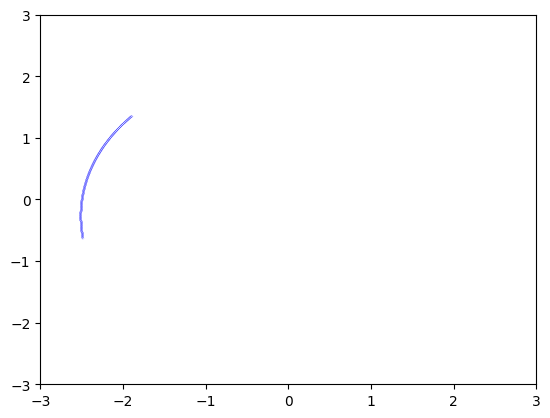

In [5]:
norm_len = (spiral_length - spiral_length.min()) / spiral_length.max()
index = (norm_len > 0.5) & (norm_len < 0.6) 
plt.scatter(x_spiral[index] / 1.5, y_spiral[index] / 1.5, color='blue', s=0.001, label='Spiral')
ax = plt.gca()
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])

# Diffusion model

In [6]:
from diffusion.base import Net 
from itertools import pairwise


class SinusoidalPositionalEmbedding(torch.nn.Module):

    def __init__(self, size: int = 32, base: float = 1e4) -> None:
        super().__init__()
        self.w = torch.nn.Parameter(base**torch.arange(0, -1, -2 / size)[None])

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        wt = self.w * t[:, None]
        return torch.stack((wt.sin(), wt.cos()), 2).flatten(1)

class SimpleCondNet(Net):

    class Block(torch.nn.Module):
        def __init__(self, input_dim, condition_dim, output_dim, use_activation=True):
            super().__init__()
            self.use_activation = use_activation
            self.x_encoder = torch.nn.Linear(input_dim, output_dim)
            self.c_encoder = torch.nn.Sequential(
                torch.nn.Linear(condition_dim, output_dim),
                torch.nn.ReLU(),
                torch.nn.Linear(output_dim, output_dim)
            )
        
        def forward(self, x, c):
            x = self.x_encoder(x)
            c = self.c_encoder(c)
            return torch.nn.functional.relu(x + c) if self.use_activation else x + c

    def __init__(self, input_dim, condition_dim, condition_emb_dim, inner_dim: list[int], condition_encoder_dim: list[int] | None=None, **kwargs):
        super().__init__()
        condition_encoder_dim = condition_encoder_dim or []

        self.time_encoder = SinusoidalPositionalEmbedding(condition_emb_dim)

        self.condition_encoder = torch.nn.Sequential()
        for in_dim, out_dim in pairwise([condition_dim] + condition_encoder_dim + [condition_emb_dim]):
            self.condition_encoder.append(torch.nn.Linear(in_dim, out_dim))
            self.condition_encoder.append(torch.nn.ReLU())

        self.blocks = torch.nn.ModuleList([
            SimpleCondNet.Block(in_dim, condition_emb_dim, out_dim) 
            for in_dim, out_dim in pairwise([input_dim] + inner_dim)
        ])
        self.blocks.append(SimpleCondNet.Block(inner_dim[-1], condition_emb_dim, input_dim, use_activation=False))

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        c = self.condition_encoder(y.float()) + self.time_encoder(t.float())
        for block in self.blocks:
            x = block(x, c)
        return x
    

class SimpleNet(torch.nn.Module):

    class Block(torch.nn.Module):
        def __init__(self, input_dim, condition_dim, output_dim, use_activation=True):
            super().__init__()
            self.use_activation = use_activation
            self.x_encoder = torch.nn.Linear(input_dim, output_dim)
            self.c_encoder = torch.nn.Sequential(
                torch.nn.Linear(condition_dim, output_dim),
                torch.nn.ReLU(),
                torch.nn.Linear(output_dim, output_dim)
            )
        
        def forward(self, x, c):
            x = self.x_encoder(x)
            c = self.c_encoder(c)
            return torch.nn.functional.relu(x + c) if self.use_activation else x + c

    def __init__(self, input_dim, condition_emb_dim, inner_dim: list[int], **kwargs):
        super().__init__()
        self.time_encoder = SinusoidalPositionalEmbedding(condition_emb_dim)
        self.blocks = torch.nn.ModuleList([
            SimpleCondNet.Block(in_dim, condition_emb_dim, out_dim) 
            for in_dim, out_dim in pairwise([input_dim] + inner_dim)
        ])
        self.blocks.append(SimpleCondNet.Block(inner_dim[-1], condition_emb_dim, input_dim, use_activation=False))

    def forward(self, x: torch.Tensor, t: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        c = self.time_encoder(t.float())
        for block in self.blocks:
            x = block(x, c)
        return x

n = SimpleCondNet(2, 1, 64, [128, 128, 128, 128])
n(torch.tensor([[100, 0.5]]).float(), torch.tensor([Y_len[0]]).float(), torch.tensor([0]))

tensor([[-1.8588, -1.1792]], grad_fn=<AddBackward0>)

# DDPM

tensor(0.0201)


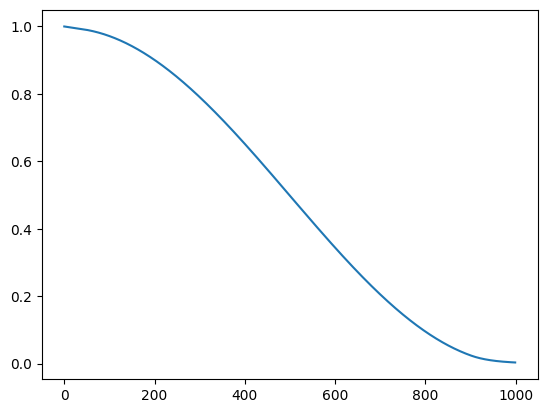

In [7]:
class CosineScheduler:
    clip_max_value = torch.Tensor([0.999])

    def __init__(self, T: int, s: float = 0.008, beta_min=0.0001, beta_max=0.02):
        """
        Cosine variance scheduler.
        The equation for the variance is:
            alpha_hat = min(cos((t / T + s) / (1 + s) * pi / 2)^2, 0.999)
        The equation for the beta is:
            beta = 1 - (alpha_hat(t) / alpha_hat(t - 1))
        The equation for the beta_hat is:
            beta_hat = (1 - alpha_hat(t - 1)) / (1 - alpha_hat(t)) * beta(t)
        """
        self.T = T
        self._alpha_hats = self._alpha_hat_function(torch.arange(self.T), T, s)
        self._alpha_hats_t_minus_1 = torch.roll(self._alpha_hats, shifts=1, dims=0) # shift forward by 1 so that alpha_first[t] = alpha[t-1]
        self._alpha_hats_t_minus_1[0] = self._alpha_hats_t_minus_1[1]  # to remove first NaN value
        self._betas = 1.0 - self._alpha_hats / self._alpha_hats_t_minus_1
        
        self._betas = torch.clip(self._betas, beta_min, beta_max)
        self._alphas = 1.0 - self._betas
        self._alpha_hats = torch.cumprod(self._alphas, dim=0)
        self._betas_hat = (1 - self._alpha_hats_t_minus_1) / (1 - self._alpha_hats) * self._betas
        self._betas_hat[torch.isnan(self._betas_hat)] = 0.0

    def _alpha_hat_function(self, t: torch.Tensor, T: int, s: float):
        """
        Compute the alpha_hat value for a given t value.
        :param t: the t value
        :param T: the total amount of noising steps
        :param s: smoothing parameter
        """
        cos_value = torch.pow(torch.cos((t / T + s) / (1 + s) * torch.pi / 2.0), 2)
        return cos_value

    def get_alpha_hat(self):
        return self._alpha_hats

    def get_alphas(self):
        return self._alphas

    def get_betas(self):
        return self._betas

    def get_betas_hat(self):
        return self._betas_hat
    
s = CosineScheduler(1000, 0.0002, 0.0002, 0.02)
plt.plot(s.get_alpha_hat())
print(s.get_betas_hat().max())

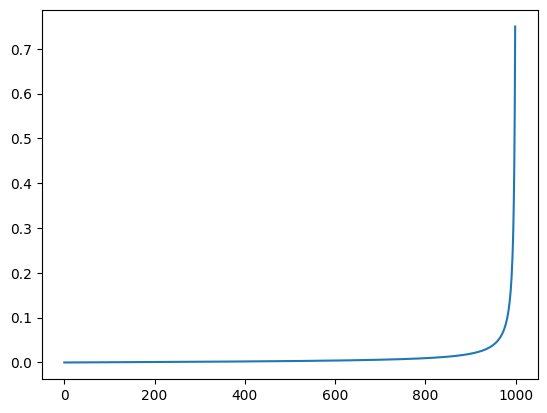

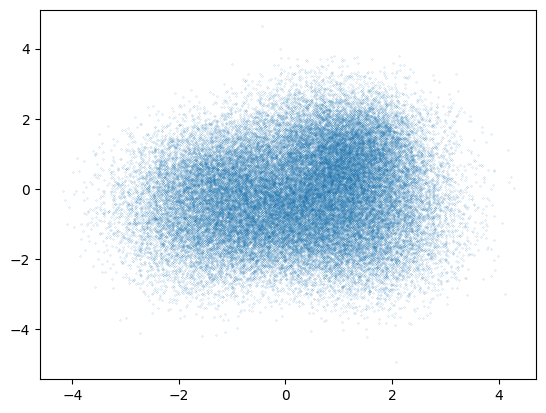

In [8]:
from typing import Any
import pytorch_lightning as pl
from dataclasses import dataclass, asdict
import tqdm 


@dataclass
class NetworkConfig:
    input_dim: int
    condition_emb_dim: int
    inner_dim: list[int]


class DDPM(pl.LightningModule):
    def __init__(self, network_config: NetworkConfig):
        super().__init__()
        self.save_hyperparameters()
        self.network_config = network_config
        self.net = SimpleNet(**asdict(network_config))

        # forward process parameters 
        self.diffusion_steps = 1000
        self.variance_scheduler = CosineScheduler(1000, 0.00001, 0.000001, 0.99)
        self.betas = self.variance_scheduler.get_betas().to(self.device)
        self.alphas = self.variance_scheduler.get_alphas().to(self.device)
        self.alphas_hat = self.variance_scheduler.get_alpha_hat().to(self.device)

    def _params_to_device(self, device: torch.device):
        self.betas = self.betas.to(device)
        self.alphas = self.alphas.to(device)
        self.alphas_hat = self.alphas_hat.to(device)
    
    def on_train_start(self) -> None:
        self._params_to_device(self.device)

    def forward(self, x, t, y=None):
        return self.net(x, t, y)
    
    def forward_diffusion(self, x_0, t, eps=None):
        """q(x_t | x_0)"""
        eps = torch.randn_like(x_0) if eps is None else eps
        alpha_hat_t = self.alphas_hat[t].view(-1, *([1] * (x_0.dim() - 1)))
        return torch.sqrt(alpha_hat_t) * x_0 + torch.sqrt(1 - alpha_hat_t) * eps

    
    def training_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int):
        batch_size = batch[0].size(0)
        device = self.device

        X_0, Y = batch
        t = torch.randint(0, self.diffusion_steps - 1, (batch_size, ), device=device)
        noise = torch.randn_like(X_0, device=device)
        X_T = self.forward_diffusion(X_0, t, noise)
        noise_pred = self.forward(X_T, t, Y)
        loss = torch.nn.functional.mse_loss(noise_pred, noise)

        self.log('training_loss', loss, prog_bar=True)
        return loss
    
    def configure_optimizers(self):
        return torch.optim.Adam(self.net.parameters(), lr=1e-4)
    
    @torch.no_grad()
    def sample(self, num_samples: int, return_intemediates: bool = False, show_progress: bool = False, Y: torch.Tensor | None = None):
        device = self.device
        self._params_to_device(device)
        if Y is not None:
            assert Y.size(0) == num_samples

        X_T = torch.randn(num_samples, self.network_config.input_dim, device=device)
        intermediates = []
        sigmas = torch.sqrt(self.betas)
        for t in tqdm.tqdm(range(self.diffusion_steps - 1, -1, -1), total=self.diffusion_steps, desc="Sampling", disable=not show_progress):
            noise_pred = self.forward(X_T, torch.tensor([t], device=device), Y)
            alpha = self.alphas[t]
            alpha_hat = self.alphas_hat[t]
            
            X_T_denoised_tmp = (1 / torch.sqrt(alpha)) * \
                (X_T - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * noise_pred)
            X_T = X_T_denoised_tmp if t == 0 else X_T_denoised_tmp + sigmas[t] * torch.randn_like(X_T)
            intermediates.append(X_T)
        return torch.stack(intermediates) if return_intemediates else X_T.unsqueeze(0)
    
ddpm = DDPM(NetworkConfig(2, 64, [128, 128, 128, 128]))
forwarded_X = ddpm.forward_diffusion(torch.tensor(X).float(), 500)
plt.plot(ddpm.betas.cpu().numpy())
plt.show()
plt.scatter(forwarded_X[:, 0], forwarded_X[:, 1], s=0.01)
plt.show()

In [9]:
from math import ceil

class Save2DSamples(pl.Callback):
    def __init__(self, save_dir: Path, num_samples: int):
        super().__init__()
        self.save_dir = save_dir
        self.num_samples = num_samples
        self.save_dir.mkdir(exist_ok=True, parents=True)

    def on_train_epoch_start(self, trainer, pl_module: DDPM):
        if trainer.current_epoch % 5 == 0:
            self.custom_evaluation(trainer.current_epoch, pl_module)

    def save_points_grid(self, X, title, path):
        # X [time x batch x coordinates]
        xmin, xmax = -3, 3
        ymin, ymax = -3, 3
        n_rows, n_cols = ceil(X.shape[0] / 3), 3
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 25))
        for i in range(X.shape[0]):
            ax = axs[i // n_cols, i % n_cols]
            ax.scatter(X[i, :, 0], X[i, :, 1], s=5)
            ax.set_title(f"Time Step {i}")
            ax.set_aspect('equal')
            ax.set_xlim([xmin, xmax])
            ax.set_ylim([ymin, ymax])
        fig.suptitle(title)
        fig.tight_layout()
        fig.savefig(path)
        plt.close(fig)

    def custom_evaluation(self, epoch_num, pl_module: DDPM):
        pl_module.eval()
        samples = pl_module.sample(self.num_samples, return_intemediates=True, show_progress=False)
        samples = samples[torch.linspace(0, samples.shape[0] - 1, 9).int()]
        self.save_points_grid(samples.cpu().detach().numpy(), "Samples", self.save_dir / f"samples_{epoch_num}.png")
        pl_module.train()

In [9]:
import torch.utils.data 

train_dataset = torch.utils.data.TensorDataset(torch.tensor(X).float(), torch.tensor(Y_len).float())
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

trainer = pl.Trainer(max_epochs=1000, callbacks=[Save2DSamples(Path("samples"), 1000)], accelerator="mps")
ddpm = DDPM(NetworkConfig(2, 50, [128, 128, 128, 128]))
# best_checkpoint_path = Path("/Users/czyjtu/dev/prompt2avatar/notebooks/training/lightning_logs/version_24/checkpoints/epoch=99-step=78900.ckpt")
# ddpm = DDPM.load_from_checkpoint(str(best_checkpoint_path))
# trainer.fit(ddpm, train_dataloaders=train_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


In [10]:
ddpm = ddpm.to("mps")
ddpm.eval()
Save2DSamples(Path("samples2"), 10000).custom_evaluation(0, ddpm)

Sampling: 100%|██████████| 1000/1000 [00:03<00:00, 270.95it/s]


# Conditional DDPM

In [10]:
from typing import Any


@dataclass 
class ConditionalNetworkConfig(NetworkConfig):
    condition_encoder_dim: list[int]
    condition_dim: int

class ConditionalDDPM(DDPM):
    def __init__(self, network_config: ConditionalNetworkConfig):
        super().__init__(network_config)
        self.net = SimpleCondNet(**asdict(network_config))

    def configure_optimizers(self):
        return torch.optim.Adam(self.net.parameters(), lr=1e-4)

class ConditionalSave2DSamples(Save2DSamples):
    def __init__(self, save_dir: Path, Y):
        super().__init__(save_dir, num_samples=len(Y))
        self.Y = Y

    def custom_evaluation(self, epoch_num, pl_module):
        pl_module.eval()
        self.Y = self.Y.to(pl_module.device)
        samples = pl_module.sample(self.num_samples, return_intemediates=True, show_progress=True, Y=torch.tensor(self.Y).float())
        samples = samples[torch.linspace(0, samples.shape[0] - 1, 9).int()]
        self.save_points_grid(samples.cpu().detach().numpy(), "Samples", self.save_dir / f"samples_{epoch_num}.png")
        pl_module.train()

## LTR

In [12]:
TRAIN_LTR = False
LTR_CHECKPOINT_PATH = Path("/Users/czyjtu/dev/prompt2avatar/notebooks/training/lightning_logs/version_48/checkpoints/epoch=718-step=567291.ckpt")

In [13]:
import torch.utils.data 

train_ltr_dataset = torch.utils.data.TensorDataset(torch.tensor(X).float(), torch.tensor(Y_ltr).reshape(-1, 1).float())
train_ltr_loader = torch.utils.data.DataLoader(train_ltr_dataset, batch_size=64, shuffle=True)

if TRAIN_LTR:
    cond_ddpm = ConditionalDDPM(ConditionalNetworkConfig(input_dim=2, condition_dim=1, condition_emb_dim=50, inner_dim=[128, 128, 128, 128], condition_encoder_dim=[50]))
    callback_Y = torch.linspace(Y_ltr.min(), Y_ltr.max(), 3000).view(-1, 1)
    # print(Y_ltr.shape())
    callback = ConditionalSave2DSamples(Path("samples_ltr"), callback_Y)
    trainer = pl.Trainer(max_epochs=1000, callbacks=[callback], accelerator="mps")
    # best_checkpoint_path = Path("/Users/czyjtu/dev/prompt2avatar/notebooks/training/lightning_logs/version_24/checkpoints/epoch=99-step=78900.ckpt")
    # ddpm = DDPM.load_from_checkpoint(str(best_checkpoint_path))
    # callback.custom_evaluation(0, cond_ddpm)
    # cond_ddpm.forward(torch.tensor([[0.5, 0.5]]).float(), torch.tensor([0]).float(), torch.tensor([0.5]).float())
    trainer.fit(cond_ddpm, train_dataloaders=train_ltr_loader)
else:
    cond_ddpm = ConditionalDDPM.load_from_checkpoint(str(LTR_CHECKPOINT_PATH))
    cond_ddpm = cond_ddpm.to("cpu")
    cond_ddpm.eval()

### Eval LTR network

In [14]:
Y_ltr.min(), Y_ltr.max()

(0.0, 2.0000000000000004)

Sampling: 100%|██████████| 1000/1000 [00:04<00:00, 221.01it/s]


(-3.0, 3.0)

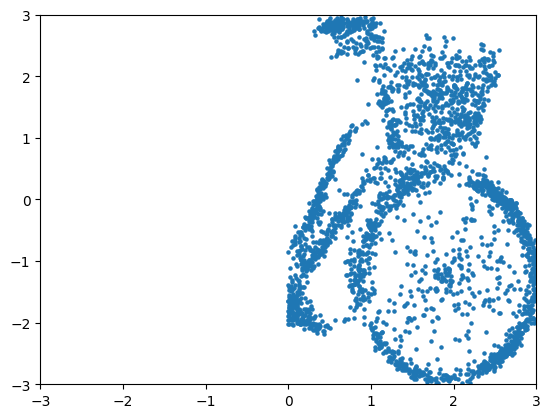

In [15]:
samples = cond_ddpm.sample(3000, return_intemediates=True, show_progress=True, Y=torch.linspace(1, 2, 3000).view(-1, 1).float())
plt.scatter(samples[-1:, :, 0], samples[-1:, :, 1], s=5)
ax = plt.gca()
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])

## Spiral length

In [11]:
class SimpleCondNetV2(Net):

    class Block(torch.nn.Module):
        def __init__(self, input_dim, condition_dim, output_dim, use_activation=True):
            super().__init__()
            self.use_activation = use_activation
            self.x_encoder = torch.nn.Linear(input_dim, output_dim)
            self.c_encoder = torch.nn.Sequential(
                torch.nn.Linear(condition_dim, output_dim),
                torch.nn.ReLU(),
                torch.nn.Linear(output_dim, output_dim)
            )
            self.t_encoder =  torch.nn.Sequential(
                torch.nn.Linear(condition_dim, output_dim),
                torch.nn.ReLU(),
                torch.nn.Linear(output_dim, output_dim)
            )
            self.concat_layer = torch.nn.Linear(output_dim * 3, output_dim)
        
        def forward(self, x, c, t):
            x = self.x_encoder(x)
            c = self.c_encoder(c)
            t = self.t_encoder(t)
            if t.shape[0] == 1:
                t = t.repeat(x.shape[0], 1)
            x = self.concat_layer(torch.cat([x, c, t], dim=-1))
            return torch.nn.functional.relu(x) if self.use_activation else x

    def __init__(self, input_dim, condition_dim, condition_emb_dim, inner_dim: list[int], condition_encoder_dim: list[int] | None=None, **kwargs):
        super().__init__()
        condition_encoder_dim = condition_encoder_dim or []

        self.time_encoder = SinusoidalPositionalEmbedding(condition_emb_dim)

        self.condition_encoder = torch.nn.Sequential()
        for in_dim, out_dim in pairwise([condition_dim] + condition_encoder_dim + [condition_emb_dim]):
            self.condition_encoder.append(torch.nn.Linear(in_dim, out_dim))
            self.condition_encoder.append(torch.nn.ReLU())

        self.blocks = torch.nn.ModuleList([
            SimpleCondNetV2.Block(in_dim, condition_emb_dim, out_dim) 
            for in_dim, out_dim in pairwise([input_dim] + inner_dim)
        ])
        self.blocks.append(SimpleCondNetV2.Block(inner_dim[-1], condition_emb_dim, input_dim, use_activation=False))

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        y = self.condition_encoder(y.float()) 
        t = self.time_encoder(t.float())
        for block in self.blocks:
            x = block(x, y, t)
        return x
    
class CondDDPMV2(DDPM):
    def __init__(self, network_config: ConditionalNetworkConfig):
        super().__init__(network_config)
        self.net = SimpleCondNetV2(**asdict(network_config))

In [24]:
TRAIN_LEN = False
LEN_CHECKPOINT_PATH = Path("/Users/czyjtu/dev/prompt2avatar/notebooks/training/lightning_logs/version_65/checkpoints/epoch=272-step=107835.ckpt")
ANGLE_CHECKPOINT_PATH = Path("/Users/czyjtu/dev/prompt2avatar/notebooks/training/lightning_logs/version_63/checkpoints/epoch=999-step=395000.ckpt")

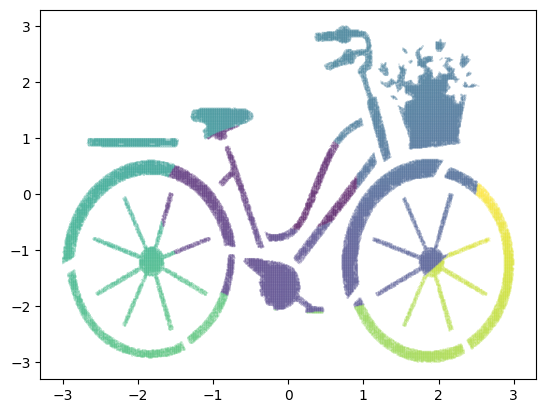

In [25]:
plt.scatter(X[:, 0], X[:, 1], c=Y_len, s=0.01)

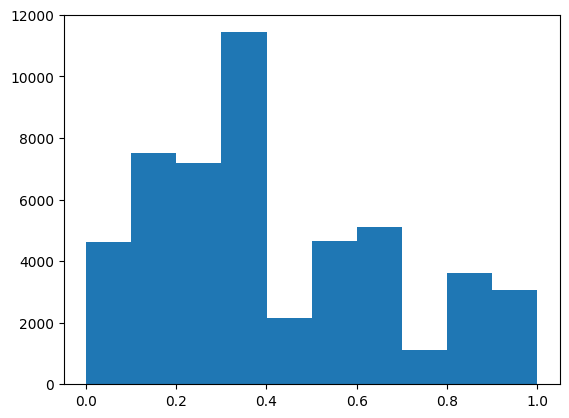

In [26]:
# plot histogram of the lengths
plt.hist(Y_len, bins=10)
plt.show()

In [27]:
import torch.utils.data 

train_len_dataset = torch.utils.data.TensorDataset(torch.tensor(X).float(), torch.tensor(Y_len).reshape(-1, 1).float())
train_len_loader = torch.utils.data.DataLoader(train_len_dataset, batch_size=128, shuffle=True)

if TRAIN_LEN:
    ddpm_len = CondDDPMV2(ConditionalNetworkConfig(input_dim=2, condition_dim=1, condition_emb_dim=128, inner_dim=[256, 256, 256, 256, 256], condition_encoder_dim=[128, 128, 128, 128]))
    callback_Y = torch.linspace(Y_len.min(), Y_len.max(), 3000).view(-1, 1)
    # print(Y_ltr.shape())
    callback = ConditionalSave2DSamples(Path("samples_len_v3"), callback_Y)
    trainer = pl.Trainer(max_epochs=1000, callbacks=[callback], accelerator="mps")
    trainer.fit(ddpm_len, train_dataloaders=train_len_loader)
else:
    cond_ddpm = CondDDPMV2.load_from_checkpoint(str(LEN_CHECKPOINT_PATH))
    cond_ddpm = cond_ddpm.to("cpu")
    cond_ddpm.eval()

### Eval spiral length network

Sampling: 100%|██████████| 1000/1000 [00:26<00:00, 38.03it/s]


(-3.0, 3.0)

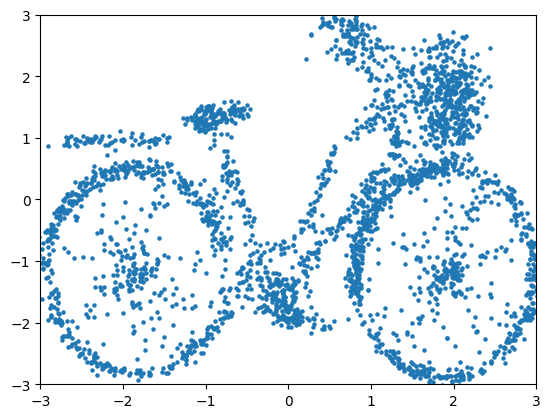

In [28]:
# sample y from training data 
index = np.random.choice(len(Y_len), 3000)
samples = cond_ddpm.sample(3000, return_intemediates=True, show_progress=True, Y=torch.tensor(Y_len[index]).view(-1, 1).float())
plt.scatter(samples[-1:, :, 0], samples[-1:, :, 1], s=5)
ax = plt.gca()
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])

Sampling: 100%|██████████| 1000/1000 [00:26<00:00, 38.38it/s]


(-3.0, 3.0)

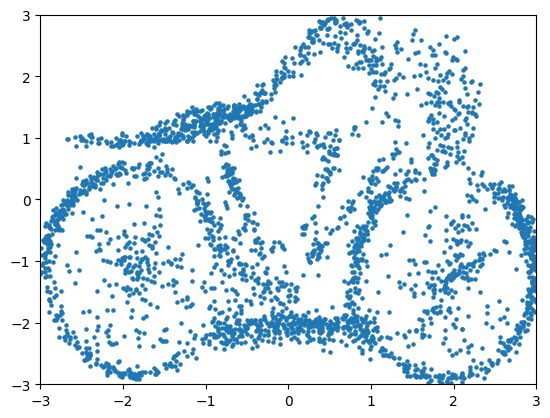

In [29]:
# sample y from uniform distribution
index = torch.linspace(Y_len.min(), Y_len.max(), 3000).view(-1, 1)
samples = cond_ddpm.sample(3000, return_intemediates=True, show_progress=True, Y=index)
plt.scatter(samples[-1:, :, 0], samples[-1:, :, 1], s=5)
ax = plt.gca()
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])

Sampling: 100%|██████████| 1000/1000 [00:12<00:00, 82.58it/s]


(-3.0, 3.0)

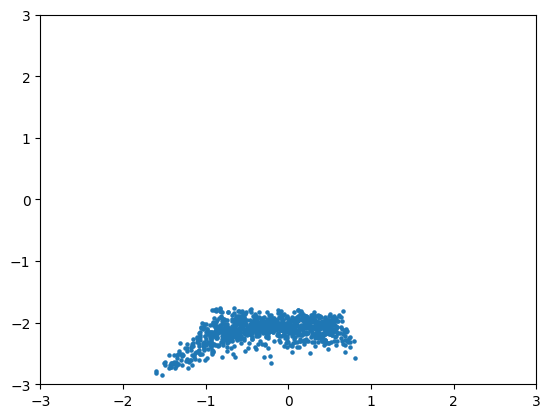

In [30]:
# condition that has not been present in training data 
index = torch.linspace(0.7, 0.8, 1000).view(-1, 1)
samples = cond_ddpm.sample(1000, return_intemediates=True, show_progress=True, Y=index)
plt.scatter(samples[-1:, :, 0], samples[-1:, :, 1], s=5)
ax = plt.gca()
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])

## Spiral closest

In [21]:
TRAIN_SPIRAL = False
SPIRAL_CHECKPOINT_PATH = Path("/Users/czyjtu/dev/prompt2avatar/notebooks/training/lightning_logs/version_61/checkpoints/epoch=244-step=193305.ckpt")

In [24]:
Y_closest = torch.tensor(Y_closest).float()
train_closest_dataset = torch.utils.data.TensorDataset(torch.tensor(X).float(), Y_closest)
train_closest_loader = torch.utils.data.DataLoader(train_closest_dataset, batch_size=64, shuffle=True)

if TRAIN_SPIRAL:
    cond_ddpm = ConditionalDDPM(ConditionalNetworkConfig(input_dim=2, condition_dim=2, condition_emb_dim=50, inner_dim=[128, 128, 128, 128], condition_encoder_dim=[50]))
    callback_Y = Y_closest[torch.linspace(0, len(Y_closest) - 1, 3000).int()]
    # print(Y_ltr.shape())
    callback = ConditionalSave2DSamples(Path("samples_closest"), callback_Y)
    trainer = pl.Trainer(max_epochs=1000, callbacks=[callback], accelerator="mps")
    # best_checkpoint_path = Path("/Users/czyjtu/dev/prompt2avatar/notebooks/training/lightning_logs/version_24/checkpoints/epoch=99-step=78900.ckpt")
    # ddpm = DDPM.load_from_checkpoint(str(best_checkpoint_path))
    # callback.custom_evaluation(0, cond_ddpm)
    # cond_ddpm.forward(torch.tensor([[0.5, 0.5]]).float(), torch.tensor([0]).float(), torch.tensor([0.5]).float())
    trainer.fit(cond_ddpm, train_dataloaders=train_closest_loader)
else:
    cond_ddpm = ConditionalDDPM.load_from_checkpoint(str(SPIRAL_CHECKPOINT_PATH))
    cond_ddpm = cond_ddpm.to("cpu")
    cond_ddpm.eval()

/var/folders/j2/83k2pfk133n_vkpjy9xj72c00000gn/T/ipykernel_97437/1451239756.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y_closest = torch.tensor(Y_closest).float()


### Eval Spiral length network

Sampling: 100%|██████████| 1000/1000 [00:15<00:00, 64.16it/s]


(-3.0, 3.0)

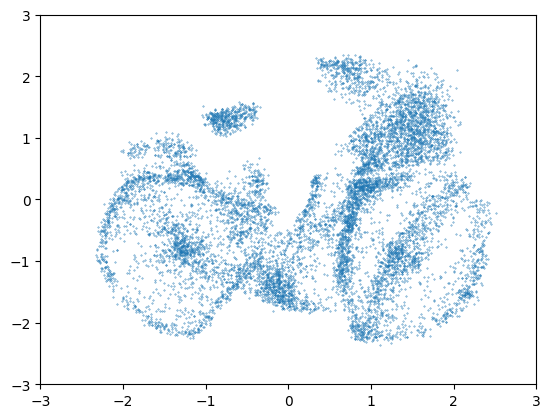

In [39]:
Y_spiral_condtion = torch.tensor(np.column_stack((x_spiral, y_spiral)).astype(float)).float()
samples = cond_ddpm.sample(10000, return_intemediates=True, show_progress=True, Y=Y_closest[torch.linspace(1, len(Y_closest)-1, 10000).int()] / 1.5)
plt.scatter(samples[-1:, :, 0], samples[-1:, :, 1], s=0.1)
ax = plt.gca()
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])

# Brudnopis

In [ ]:

# file = Path(__name__)
# input = file.parent / "data_test/in"
# output = file.parent / "data_test/out" / file.stem
# output.mkdir(parents=True, exist_ok=True)
# torch.set_float32_matmul_precision("high")
# torch.set_grad_enabled(False)

# X = torch.tensor(X, dtype=torch.float32)
# # Y = torch.tensor(Y, dtype=torch.float32)

# net = SimpleNet(input_dim=2, condition_emb_dim=50, inner_dim=[128, 128, 128])

# model = diffusion.Model(
#     data=Identity(X, None, batch=128, shuffle=True),
#     schedule=Cosine(steps=1000),
#     noise=Gaussian(parameter="epsilon", variance="fixed"),
#     net=net,
#     loss=Simple(parameter="epsilon"),
#     device="mps",
#     compile=False,
#     optimizer=torch.optim.Adam(net.parameters(), lr=1e-4),
# )

# if (output / "model.pt").exists():
#     model.load(output / "model.pt")
# epoch = sum(1 for _ in output.glob("[0-9]*"))

# def save_points_grid(X, title, path):
#     from math import ceil 
#     # X [time x batch x coordinates]
#     n_rows, n_cols = ceil(X.shape[0] / 3), 3
#     fig, axs = plt.subplots(n_rows, n_cols, figsize=(15, 25))
#     for i in range(X.shape[0]):
#         ax = axs[i // n_cols, i % n_cols]
#         ax.scatter(X[i, :, 0], X[i, :, 1], s=5)
#         ax.set_title(f"Time Step {i}")
#         ax.set_aspect('equal')
#     fig.suptitle(title)
#     fig.tight_layout()
#     fig.savefig(path)
#     plt.close(fig)

# for epoch, loss in enumerate(model.train(epochs=100, progress=True), 1):
#     z = model.sample(batch=100, progress=False)
#     z = z[torch.linspace(0, z.shape[0] - 1, 10).int()]
#     # z [time x batch x coordinates]
#     z = z.cpu().numpy()
#     save_points_grid(z, f"Epoch {epoch} - Loss {loss:.2e}", output / f"{epoch:03d}.png")
#     model.save(output / "model.pt")

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Generate random data for each subplot
# num_points = 100
# x_data = np.random.randn(9, num_points)
# y_data = np.random.randn(9, num_points)

# # Create a 3x3 grid of scatter plots
# fig, axs = plt.subplots(3, 3, figsize=(12, 12))

# # Plot each scatter plot in the grid
# for i in range(3):
#     for j in range(3):
#         ax = axs[i, j]
#         ax.scatter(x_data[i * 3 + j], y_data[i * 3 + j], color='blue', alpha=0.6)
#         ax.set_xlabel('X')
#         ax.set_ylabel('Y')
#         ax.set_title(f'Scatter Plot {i * 3 + j + 1}')

# # Adjust layout to prevent overlap
# plt.tight_layout()
# plt.show()

In [ ]:
print(z.shape)

(10, 100, 2)
